In [22]:
# ============================================================
# CELL 1 – CLUSTER 4 – Setup e Caricamento Dati
# ============================================================

# --- Installazione skfuzzy ---
import subprocess
import sys

print("Installazione librerie mancanti...")
subprocess.check_call([sys.executable, "-m", "pip",
                       "install", "scikit-fuzzy",
                       "-q"])
print("scikit-fuzzy installato!")

# --- Import standard ---
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Import sklearn ---
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier

# --- Import skfuzzy ---
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# --- Import tqdm ---
from tqdm.notebook import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (12, 5)

print("Tutte le librerie importate correttamente!")

# --- Parametri globali ---
id_cols     = ['subject_id', 'hadm_id', 'stay_id',
               'ICU', 'ICU_intime', 'ICU_outtime']
outcome_col = 'outcome'
join_cols   = ['subject_id', 'hadm_id', 'stay_id']
cluster_col = 'cluster_id'
CLUSTER_ID  = 4   # ← Cluster 4

print(f"\n Parametri globali:")
print(f"   → Cluster selezionato : {CLUSTER_ID}")
print(f"   → Outcome column      : {outcome_col}")
print(f"   → Random state        : {RANDOM_STATE}")


Installazione librerie mancanti...
scikit-fuzzy installato!
Tutte le librerie importate correttamente!

 Parametri globali:
   → Cluster selezionato : 4
   → Outcome column      : outcome
   → Random state        : 42


In [23]:
# ============================================================
# CELL 2 – CLUSTER 4 – Upload e Caricamento Dataset
# ============================================================

import os
from google.colab import files

# ── Funzione helper per caricare un file ──
def upload_if_missing(filename):
    if not os.path.exists(filename):
        print(f"  File '{filename}' non trovato.")
        print(f" Carica il file '{filename}':")
        uploaded = files.upload()
        if filename not in uploaded:
            raise FileNotFoundError(
                f" File '{filename}' non caricato!"
            )
        print(f" '{filename}' caricato!")
    else:
        print(f" '{filename}' già presente!")

# ── Carica dataset principale ──
upload_if_missing("Dataset_DAPPC_2026.xlsx")

# ── Carica assignments SOM ──
os.makedirs("Assignments", exist_ok=True)

assignment_file = "Assignments/subject_assignments_10x10.xlsx"
if not os.path.exists(assignment_file):
    print(f"\n  File assignments non trovato.")
    print(f" Carica 'subject_assignments_10x10.xlsx':")
    uploaded = files.upload()
    # Sposta nella cartella Assignments
    for fname in uploaded:
        os.rename(fname,
                  f"Assignments/{fname}")
        print(f" '{fname}' spostato in Assignments/")
else:
    print(f" '{assignment_file}' già presente!")

# ── Carica dataset ──
df_full      = pd.read_excel("Dataset_DAPPC_2026.xlsx")
feature_cols = [c for c in df_full.columns
                if c not in id_cols + [outcome_col]]

print(f"\n Dataset caricato!")
print(f"   → Shape totale   : {df_full.shape}")
print(f"   → Feature totali : {len(feature_cols)}")

# ── Carica assignments ──
best_assignment = pd.read_excel(assignment_file)

print(f"\n Assignments SOM 10x10 caricati!")
print(f"   → Shape : {best_assignment.shape}")

# ── Merge con cluster assignments ──
df = df_full.merge(
    best_assignment[join_cols + [cluster_col]],
    on=join_cols,
    how='inner'
)

# ── Filtra Cluster 4 ──
cluster_df = df[df[cluster_col] == CLUSTER_ID].copy()

print(f"\n Cluster {CLUSTER_ID} estratto!")
print(f"   → Shape Cluster 4 : {cluster_df.shape}")
print(f"\n Distribuzione outcome Cluster 4:")
display(cluster_df[outcome_col]
        .value_counts()
        .sort_index()
        .rename({
            0: '0–Extubation Failure',
            1: '1–Extubation Success',
            2: '2–Death during ICU'
        }))


 'Dataset_DAPPC_2026.xlsx' già presente!
 'Assignments/subject_assignments_10x10.xlsx' già presente!

 Dataset caricato!
   → Shape totale   : (4000, 120)
   → Feature totali : 113

 Assignments SOM 10x10 caricati!
   → Shape : (3893, 11)

 Cluster 4 estratto!
   → Shape Cluster 4 : (352, 121)

 Distribuzione outcome Cluster 4:


,count
outcome,
0–Extubation Failure,68
1–Extubation Success,139
2–Death during ICU,145


In [24]:
# ============================================================
# CELL 3 – CLUSTER 4 – Feature Selezionate da ACO
# ============================================================

# Feature selezionate dall'ACO per il Cluster 4
# (Setup C – Best CV Score: 0.5968, 10 features)
selected_features_cluster4 = [
    'first_plateau_pressure',
    'neuromuscular_blockers',
    'coronary_artery_disease',
    'charlson_comorbidity_index',
    'first_lactate',
    'pulmonary_hypertension',
    'std_mean_airway_pressure',
    'std_plateau_pressure',
]

print(f" Feature selezionate per Cluster 4:")
for i, f in enumerate(selected_features_cluster4, 1):
    print(f"   {i:2d}. {f}")
print(f"\n   → Totale feature : "
      f"{len(selected_features_cluster4)}")

# --- Prepara X e y ---
feature_cols_cluster4 = [
    c for c in selected_features_cluster4
    if c in cluster_df.columns
]

X_df = cluster_df[feature_cols_cluster4].copy()
y    = cluster_df[outcome_col].values

print(f"\n Matrice X e vettore y preparati!")
print(f"   → Shape X : {X_df.shape}")
print(f"   → Shape y : {y.shape}")
print(f"\n Distribuzione classi:")
display(pd.Series(y).value_counts().sort_index().rename({
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}))



 Feature selezionate per Cluster 4:
    1. first_plateau_pressure
    2. neuromuscular_blockers
    3. coronary_artery_disease
    4. charlson_comorbidity_index
    5. first_lactate
    6. pulmonary_hypertension
    7. std_mean_airway_pressure
    8. std_plateau_pressure

   → Totale feature : 8

 Matrice X e vettore y preparati!
   → Shape X : (352, 8)
   → Shape y : (352,)

 Distribuzione classi:


,count
0–Extubation Failure,68
1–Extubation Success,139
2–Death during ICU,145


In [25]:
# ============================================================
# CELL 4 – CLUSTER 4 – Imputazione e Scaling
# ============================================================

print(f"NaN in X_df prima dell'imputazione: "
      f"{X_df.isna().sum().sum()}")

# --- Imputazione con mediana ---
imputer       = SimpleImputer(strategy='median')
X_imputed_arr = imputer.fit_transform(X_df)
X_imputed     = pd.DataFrame(
    X_imputed_arr,
    columns=feature_cols_cluster4,
    index=X_df.index
)

print(f"NaN dopo imputazione: "
      f"{X_imputed.isna().sum().sum()}")

# --- Scaling Min-Max ---
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\n Imputazione e scaling completati!")
print(f"   → Shape X_imputed : {X_imputed.shape}")
print(f"   → Shape X_scaled  : {X_scaled.shape}")

# --- Statistiche descrittive ---
print(f"\n Statistiche descrittive (spazio reale):")
display(X_imputed.describe().round(3))



NaN in X_df prima dell'imputazione: 22
NaN dopo imputazione: 0

 Imputazione e scaling completati!
   → Shape X_imputed : (352, 8)
   → Shape X_scaled  : (352, 8)

 Statistiche descrittive (spazio reale):


,first_plateau_pressure,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_mean_airway_pressure,std_plateau_pressure
count,352.000,352.0,352.000,352.000,352.000,352.000,352.000,352.000
mean,19.549,0.0,0.136,4.452,3.032,0.071,2.396,2.213
std,5.405,0.0,0.344,3.011,3.024,0.257,1.144,1.341
min,8.700,0.0,0.000,0.000,0.600,0.000,0.306,0.000
25%,15.850,0.0,0.000,2.000,1.300,0.000,1.533,1.315
50%,18.000,0.0,0.000,4.000,2.000,0.000,2.291,2.053
75%,23.000,0.0,0.000,6.000,3.525,0.000,3.120,3.002
max,36.000,0.0,1.000,17.000,22.000,1.000,6.208,10.888


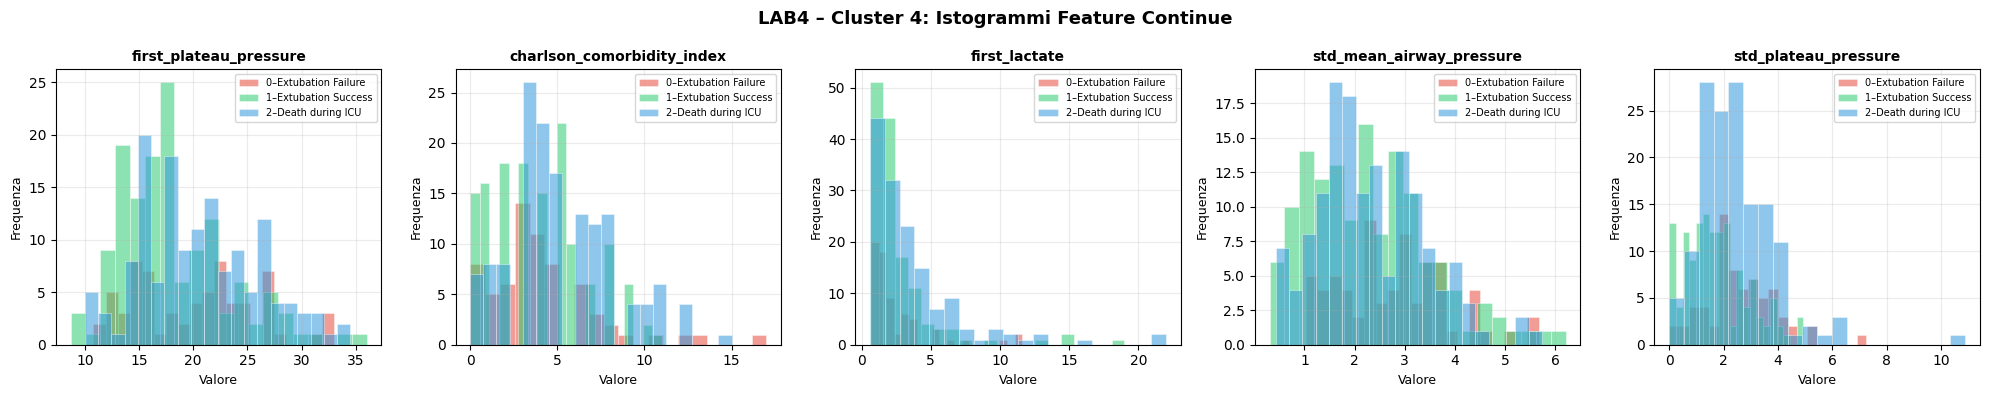

 Istogrammi salvati in 'histograms_cluster4.png'


In [26]:
# ============================================================
# CELL 5 – CLUSTER 4 – Istogrammi per Feature
# ============================================================

labels_class = {
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}
colors_class = {
    0: '#e74c3c',
    1: '#2ecc71',
    2: '#3498db'
}

continuous_features = [
    'first_plateau_pressure',
    'charlson_comorbidity_index',
    'first_lactate',
    'std_mean_airway_pressure',
    'std_plateau_pressure'
]
binary_features = [
    'neuromuscular_blockers',
    'coronary_artery_disease',
    'pulmonary_hypertension'
]

n_cont = len(continuous_features)
fig, axes = plt.subplots(1, n_cont, figsize=(20, 4))

for ax, feat in zip(axes, continuous_features):
    for c in [0, 1, 2]:
        mask   = y == c
        values = X_imputed.loc[
            X_imputed.index[mask], feat
        ]
        ax.hist(values, bins=20, alpha=0.55,
                color=colors_class[c],
                label=labels_class[c],
                edgecolor='white', linewidth=0.5)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valore', fontsize=9)
    ax.set_ylabel('Frequenza', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    'LAB4 – Cluster 4: Istogrammi Feature Continue',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('histograms_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Istogrammi salvati in 'histograms_cluster4.png'")


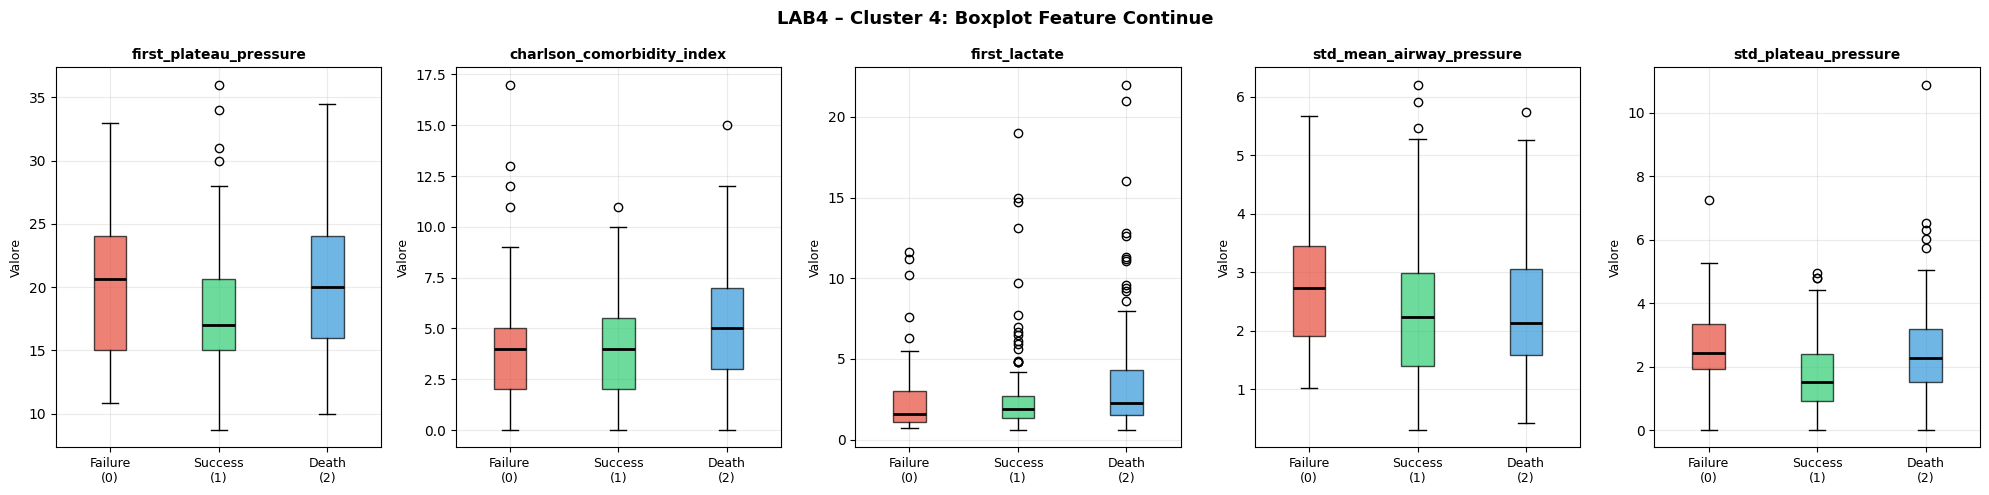

 Boxplot salvati in 'boxplots_cluster4.png'


In [27]:
# ============================================================
# CELL 6 – CLUSTER 4 – Boxplot per Feature
# ============================================================

fig, axes = plt.subplots(1, n_cont, figsize=(20, 5))

for ax, feat in zip(axes, continuous_features):
    data_box = [
        X_imputed.loc[
            X_imputed.index[y == c], feat
        ].values
        for c in [0, 1, 2]
    ]
    bp = ax.boxplot(data_box, patch_artist=True,
                    medianprops=dict(color='black',
                                    linewidth=2))
    for patch, c in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(colors_class[c])
        patch.set_alpha(0.7)

    ax.set_xticklabels(
        ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
        fontsize=9
    )
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylabel('Valore', fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    'LAB4 – Cluster 4: Boxplot Feature Continue',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('boxplots_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Boxplot salvati in 'boxplots_cluster4.png'")


In [28]:
# ============================================================
# CELL 7 – CLUSTER 4 – Definizione Universi Fuzzy
# ============================================================

# --- Range reali dal Cluster 4 ---
u_plateau  = np.linspace(
    X_imputed['first_plateau_pressure'].min(),
    X_imputed['first_plateau_pressure'].max(), 200)
u_charlson = np.linspace(
    X_imputed['charlson_comorbidity_index'].min(),
    X_imputed['charlson_comorbidity_index'].max(), 200)
u_lactate  = np.linspace(
    X_imputed['first_lactate'].min(),
    X_imputed['first_lactate'].max(), 200)
u_map      = np.linspace(
    X_imputed['std_mean_airway_pressure'].min(),
    X_imputed['std_mean_airway_pressure'].max(), 200)
u_plat_std = np.linspace(
    X_imputed['std_plateau_pressure'].min(),
    X_imputed['std_plateau_pressure'].max(), 200)
u_binary   = np.linspace(0, 1, 200)
u_risk     = np.linspace(0, 100, 200)

print(" Universi fuzzy definiti per Cluster 4:")
print(f"   → plateau_pressure : "
      f"[{u_plateau.min():.2f}, {u_plateau.max():.2f}]")
print(f"   → charlson_index   : "
      f"[{u_charlson.min():.2f}, {u_charlson.max():.2f}]")
print(f"   → first_lactate    : "
      f"[{u_lactate.min():.2f}, {u_lactate.max():.2f}]")
print(f"   → std_map          : "
      f"[{u_map.min():.2f}, {u_map.max():.2f}]")
print(f"   → std_plateau      : "
      f"[{u_plat_std.min():.2f}, {u_plat_std.max():.2f}]")


 Universi fuzzy definiti per Cluster 4:
   → plateau_pressure : [8.70, 36.00]
   → charlson_index   : [0.00, 17.00]
   → first_lactate    : [0.60, 22.00]
   → std_map          : [0.31, 6.21]
   → std_plateau      : [0.00, 10.89]


In [29]:
# ============================================================
# CELL 8 – CLUSTER 4 – Antecedenti, Conseguente e Percentili
# ============================================================

# --- Antecedenti (feature continue) ---
plateau  = ctrl.Antecedent(
    u_plateau,  'first_plateau_pressure')
charlson = ctrl.Antecedent(
    u_charlson, 'charlson_comorbidity_index')
lactate  = ctrl.Antecedent(
    u_lactate,  'first_lactate')
std_map  = ctrl.Antecedent(
    u_map,      'std_mean_airway_pressure')
std_plat = ctrl.Antecedent(
    u_plat_std, 'std_plateau_pressure')

# --- Antecedenti (feature binarie) ---
nmb = ctrl.Antecedent(u_binary, 'neuromuscular_blockers')
cad = ctrl.Antecedent(u_binary, 'coronary_artery_disease')
ph  = ctrl.Antecedent(u_binary, 'pulmonary_hypertension')

# --- Conseguente ---
clinical_risk = ctrl.Consequent(u_risk, 'clinical_risk')

# --- Percentili adattivi al Cluster 4 ---
def get_percentiles(series):
    return (series.quantile(0.25),
            series.quantile(0.50),
            series.quantile(0.75))

p25_pl, p50_pl, p75_pl = get_percentiles(
    X_imputed['first_plateau_pressure'])
p25_ch, p50_ch, p75_ch = get_percentiles(
    X_imputed['charlson_comorbidity_index'])
p25_la, p50_la, p75_la = get_percentiles(
    X_imputed['first_lactate'])
p25_mp, p50_mp, p75_mp = get_percentiles(
    X_imputed['std_mean_airway_pressure'])
p25_sp, p50_sp, p75_sp = get_percentiles(
    X_imputed['std_plateau_pressure'])

print(" Percentili calcolati per Cluster 4:")
print(f"   plateau_pressure → "
      f"Q1={p25_pl:.2f} Q2={p50_pl:.2f} Q3={p75_pl:.2f}")
print(f"   charlson_index   → "
      f"Q1={p25_ch:.2f} Q2={p50_ch:.2f} Q3={p75_ch:.2f}")
print(f"   first_lactate    → "
      f"Q1={p25_la:.2f} Q2={p50_la:.2f} Q3={p75_la:.2f}")
print(f"   std_map          → "
      f"Q1={p25_mp:.2f} Q2={p50_mp:.2f} Q3={p75_mp:.2f}")
print(f"   std_plateau      → "
      f"Q1={p25_sp:.2f} Q2={p50_sp:.2f} Q3={p75_sp:.2f}")


 Percentili calcolati per Cluster 4:
   plateau_pressure → Q1=15.85 Q2=18.00 Q3=23.00
   charlson_index   → Q1=2.00 Q2=4.00 Q3=6.00
   first_lactate    → Q1=1.30 Q2=2.00 Q3=3.52
   std_map          → Q1=1.53 Q2=2.29 Q3=3.12
   std_plateau      → Q1=1.32 Q2=2.05 Q3=3.00


In [30]:
# ============================================================
# CELL 9 – CLUSTER 4 – Definizione Membership Functions
# ============================================================

# ── plateau_pressure ──
plateau['low']    = fuzz.trapmf(u_plateau,
    [u_plateau.min(), u_plateau.min(), p25_pl, p50_pl])
plateau['normal'] = fuzz.trimf(u_plateau,
    [p25_pl, p50_pl, p75_pl])
plateau['high']   = fuzz.trapmf(u_plateau,
    [p50_pl, p75_pl, u_plateau.max(), u_plateau.max()])

# ── charlson_comorbidity_index ──
charlson['low']    = fuzz.trapmf(u_charlson,
    [u_charlson.min(), u_charlson.min(), p25_ch, p50_ch])
charlson['medium'] = fuzz.trimf(u_charlson,
    [p25_ch, p50_ch, p75_ch])
charlson['high']   = fuzz.trapmf(u_charlson,
    [p50_ch, p75_ch, u_charlson.max(), u_charlson.max()])

# ── first_lactate ──
lactate['normal']   = fuzz.trapmf(u_lactate,
    [u_lactate.min(), u_lactate.min(), p25_la, p50_la])
lactate['elevated'] = fuzz.trimf(u_lactate,
    [p25_la, p50_la, p75_la])
lactate['critical'] = fuzz.trapmf(u_lactate,
    [p50_la, p75_la, u_lactate.max(), u_lactate.max()])

# ── std_mean_airway_pressure ──
std_map['stable']   = fuzz.trapmf(u_map,
    [u_map.min(), u_map.min(), p25_mp, p50_mp])
std_map['variable'] = fuzz.trimf(u_map,
    [p25_mp, p50_mp, p75_mp])
std_map['unstable'] = fuzz.trapmf(u_map,
    [p50_mp, p75_mp, u_map.max(), u_map.max()])

# ── std_plateau_pressure ──
std_plat['stable']   = fuzz.trapmf(u_plat_std,
    [u_plat_std.min(), u_plat_std.min(), p25_sp, p50_sp])
std_plat['variable'] = fuzz.trimf(u_plat_std,
    [p25_sp, p50_sp, p75_sp])
std_plat['unstable'] = fuzz.trapmf(u_plat_std,
    [p50_sp, p75_sp, u_plat_std.max(), u_plat_std.max()])

# ── Feature binarie con sigmf morbida ──
nmb['absent']  = fuzz.sigmf(u_binary, 0.3, -20)
nmb['present'] = fuzz.sigmf(u_binary, 0.7,  20)
cad['absent']  = fuzz.sigmf(u_binary, 0.3, -20)
cad['present'] = fuzz.sigmf(u_binary, 0.7,  20)
ph['absent']   = fuzz.sigmf(u_binary, 0.3, -20)
ph['present']  = fuzz.sigmf(u_binary, 0.7,  20)

# ── Output clinical_risk ──
clinical_risk['low']    = fuzz.trapmf(u_risk,
    [0,  0,  25, 40])
clinical_risk['medium'] = fuzz.trimf(u_risk,
    [30, 50, 70])
clinical_risk['high']   = fuzz.trapmf(u_risk,
    [60, 75, 100, 100])

print(" Membership Functions definite per Cluster 4!")
print(f"   → plateau    : low / normal / high")
print(f"   → charlson   : low / medium / high")
print(f"   → lactate    : normal / elevated / critical")
print(f"   → std_map    : stable / variable / unstable")
print(f"   → std_plat   : stable / variable / unstable")
print(f"   → nmb/cad/ph : absent / present (sigmf)")
print(f"   → output     : low / medium / high")


 Membership Functions definite per Cluster 4!
   → plateau    : low / normal / high
   → charlson   : low / medium / high
   → lactate    : normal / elevated / critical
   → std_map    : stable / variable / unstable
   → std_plat   : stable / variable / unstable
   → nmb/cad/ph : absent / present (sigmf)
   → output     : low / medium / high


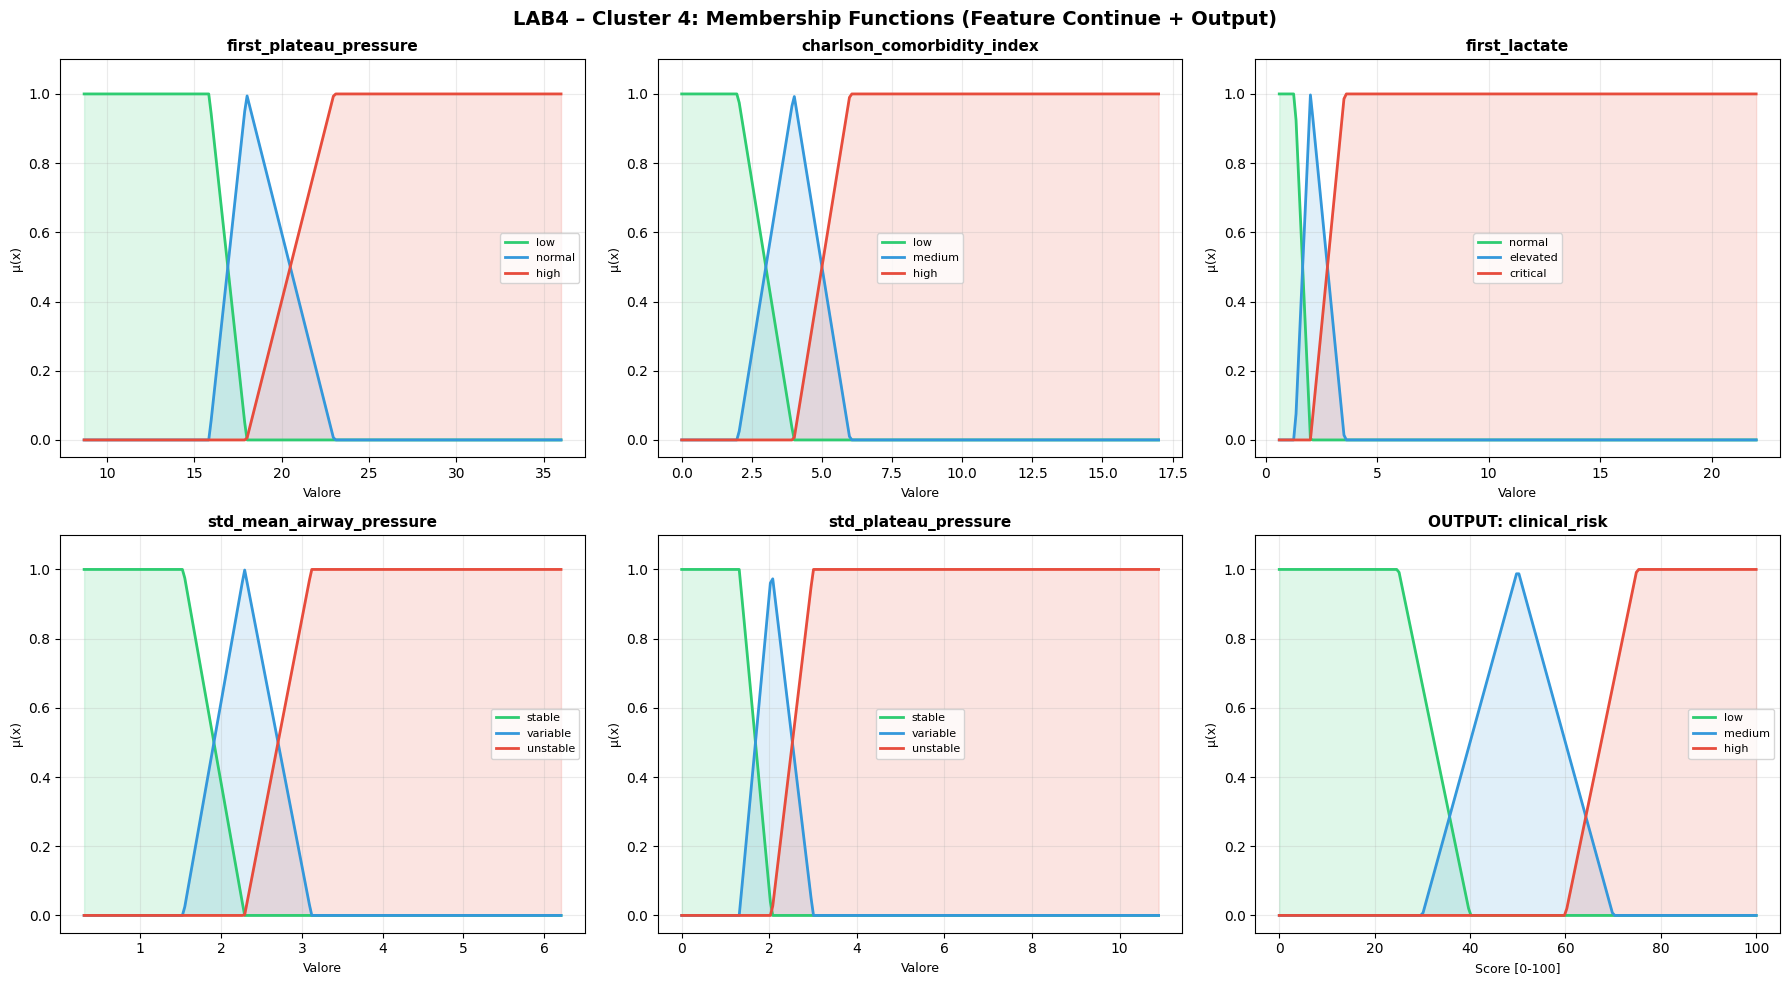

 MF continue salvate in 'MF_continuous_cluster4.png'


In [31]:
# ============================================================
# CELL 10 – CLUSTER 4 – Visualizzazione MF Continue + Output
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

mf_continuous = [
    (plateau,  'first_plateau_pressure',
     ['low','normal','high']),
    (charlson, 'charlson_comorbidity_index',
     ['low','medium','high']),
    (lactate,  'first_lactate',
     ['normal','elevated','critical']),
    (std_map,  'std_mean_airway_pressure',
     ['stable','variable','unstable']),
    (std_plat, 'std_plateau_pressure',
     ['stable','variable','unstable']),
    (clinical_risk, 'OUTPUT: clinical_risk',
     ['low','medium','high']),
]
colors_mf = ['#2ecc71', '#3498db', '#e74c3c']

for ax, (var, title, terms) in \
        zip(axes, mf_continuous):
    for term, color in zip(terms, colors_mf):
        ax.plot(var.universe, var[term].mf,
                color=color, linewidth=2, label=term)
        ax.fill_between(var.universe, var[term].mf,
                        alpha=0.15, color=color)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(
        'Valore' if title != 'OUTPUT: clinical_risk'
        else 'Score [0-100]', fontsize=9)
    ax.set_ylabel('μ(x)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_ylim([-0.05, 1.1])

fig.suptitle(
    'LAB4 – Cluster 4: Membership Functions '
    '(Feature Continue + Output)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('MF_continuous_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" MF continue salvate in "
      "'MF_continuous_cluster4.png'")


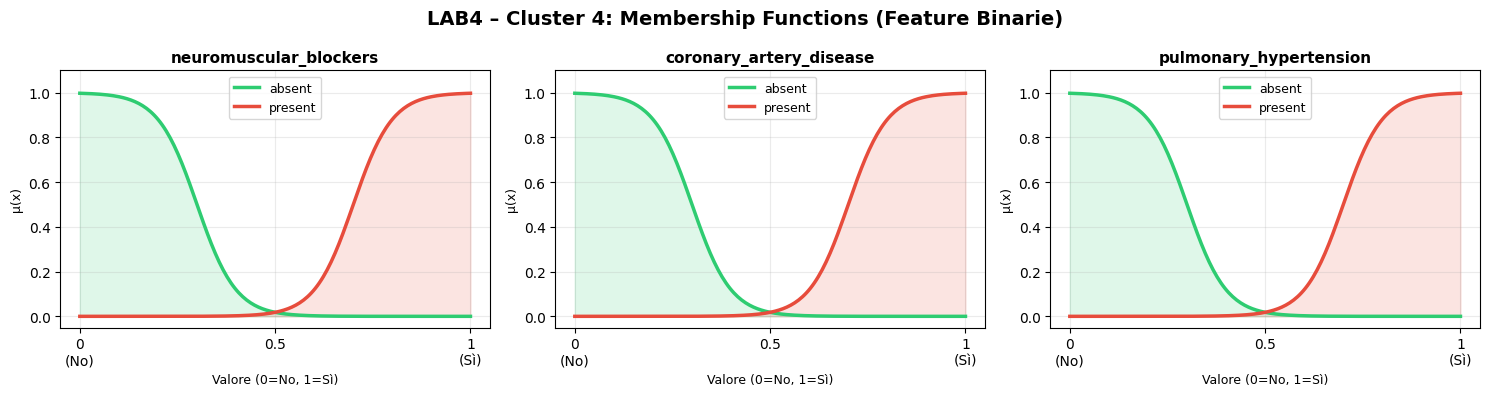

 MF binarie salvate in 'MF_binary_cluster4.png'


In [32]:
# ============================================================
# CELL 11 – CLUSTER 4 – Visualizzazione MF Binarie
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

mf_binary = [
    (nmb, 'neuromuscular_blockers'),
    (cad, 'coronary_artery_disease'),
    (ph,  'pulmonary_hypertension'),
]

for ax, (var, title) in zip(axes, mf_binary):
    ax.plot(var.universe, var['absent'].mf,
            color='#2ecc71', linewidth=2.5,
            label='absent')
    ax.fill_between(var.universe, var['absent'].mf,
                    alpha=0.15, color='#2ecc71')
    ax.plot(var.universe, var['present'].mf,
            color='#e74c3c', linewidth=2.5,
            label='present')
    ax.fill_between(var.universe, var['present'].mf,
                    alpha=0.15, color='#e74c3c')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valore (0=No, 1=Sì)', fontsize=9)
    ax.set_ylabel('μ(x)', fontsize=9)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(['0\n(No)', '0.5', '1\n(Sì)'])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_ylim([-0.05, 1.1])

fig.suptitle(
    'LAB4 – Cluster 4: '
    'Membership Functions (Feature Binarie)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('MF_binary_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" MF binarie salvate in 'MF_binary_cluster4.png'")


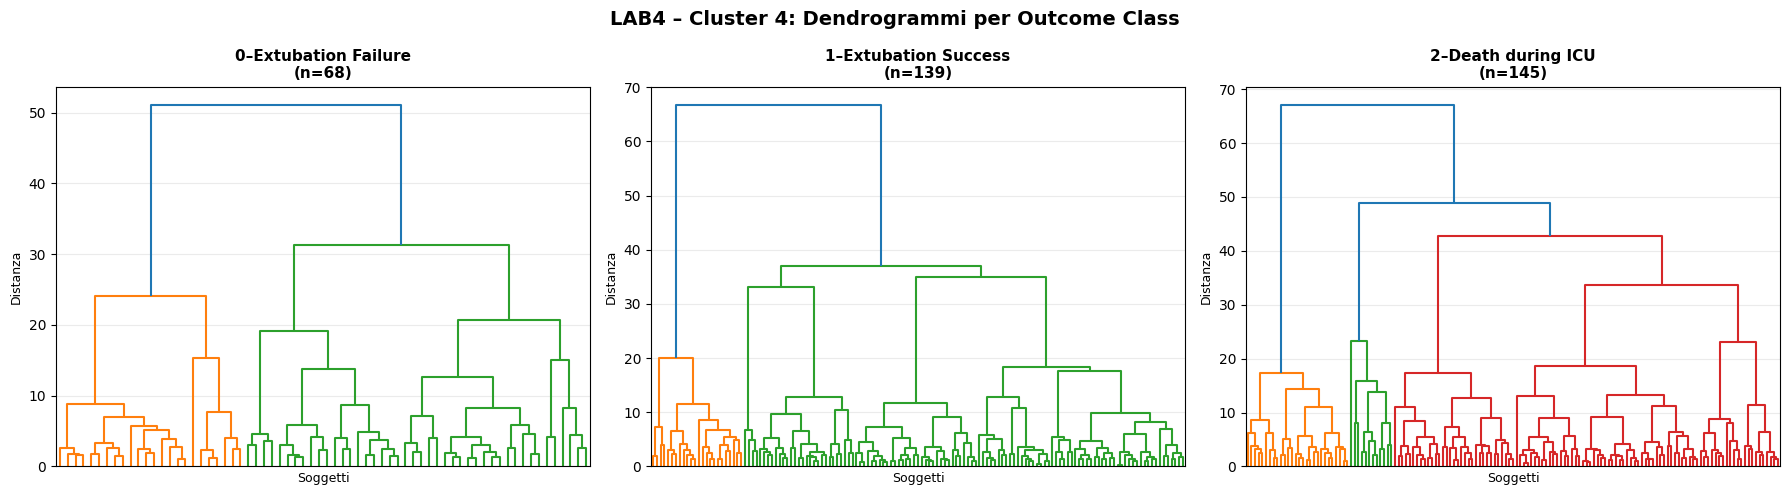

 Dendrogrammi salvati in 'dendrograms_cluster4.png'


In [33]:
# ============================================================
# CELL 12 – CLUSTER 4 – Dendrogrammi per Outcome Class
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, c in enumerate([0, 1, 2]):
    mask  = y == c
    X_sub = X_imputed[mask][continuous_features].values

    if len(X_sub) > 1:
        dist = pdist(X_sub, metric='euclidean')
        Z    = linkage(dist, method='ward')
        dendrogram(
            Z, ax=axes[idx],
            no_labels=True,
            color_threshold=0.7 * max(Z[:, 2])
        )
        axes[idx].set_title(
            f'{labels_class[c]}\n(n={mask.sum()})',
            fontsize=11, fontweight='bold'
        )
        axes[idx].set_xlabel('Soggetti', fontsize=9)
        axes[idx].set_ylabel('Distanza', fontsize=9)
        axes[idx].grid(True, alpha=0.25)

fig.suptitle(
    'LAB4 – Cluster 4: Dendrogrammi per Outcome Class',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('dendrograms_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Dendrogrammi salvati in "
      "'dendrograms_cluster4.png'")


In [34]:
# ============================================================
# CELL 13 – CLUSTER 4 – Definizione Regole FIS
# ============================================================

fuzzy_vars = {
    'first_plateau_pressure'    : plateau,
    'neuromuscular_blockers'    : nmb,
    'coronary_artery_disease'   : cad,
    'charlson_comorbidity_index': charlson,
    'first_lactate'             : lactate,
    'pulmonary_hypertension'    : ph,
    'std_mean_airway_pressure'  : std_map,
    'std_plateau_pressure'      : std_plat,
}

rules_cluster4 = [

    # RISCHIO BASSO → Extubation Success

    ctrl.Rule(
        plateau['low']    & charlson['low']   &
        lactate['normal'] & std_map['stable'],
        clinical_risk['low']
    ),
    ctrl.Rule(
        plateau['normal'] & charlson['low']   &
        lactate['normal'] & std_map['stable'],
        clinical_risk['low']
    ),
    ctrl.Rule(
        plateau['low']     & charlson['medium'] &
        lactate['normal']  & std_map['stable'],
        clinical_risk['low']
    ),
    ctrl.Rule(
        plateau['normal']  & charlson['medium'] &
        lactate['normal']  & std_map['stable'],
        clinical_risk['low']
    ),
    ctrl.Rule(
        lactate['normal'] & charlson['low'],
        clinical_risk['low']
    ),
    ctrl.Rule(
        lactate['normal'] & std_map['stable'],
        clinical_risk['low']
    ),


    # RISCHIO MEDIO → Extubation Failure

    ctrl.Rule(
        plateau['normal']   & charlson['medium']  &
        lactate['elevated'] & std_map['variable'],
        clinical_risk['medium']
    ),
    ctrl.Rule(
        plateau['normal']   & charlson['medium']  &
        lactate['elevated'] & std_map['stable'],
        clinical_risk['medium']
    ),
    ctrl.Rule(
        plateau['high']     & charlson['medium']  &
        lactate['elevated'] & std_map['stable'],
        clinical_risk['medium']
    ),
    ctrl.Rule(
        lactate['elevated'] & charlson['medium'],
        clinical_risk['medium']
    ),
    ctrl.Rule(
        plateau['high']     & std_map['variable'],
        clinical_risk['medium']
    ),
    ctrl.Rule(
        lactate['elevated'] & std_map['variable'],
        clinical_risk['medium']
    ),


    # RISCHIO ALTO → Death during ICU

    ctrl.Rule(
        charlson['high']    & lactate['critical'],
        clinical_risk['high']
    ),
    ctrl.Rule(
        plateau['high']     & lactate['critical'],
        clinical_risk['high']
    ),
    ctrl.Rule(
        lactate['critical'] & std_map['unstable'],
        clinical_risk['high']
    ),
    ctrl.Rule(
        charlson['high']    & std_map['unstable'],
        clinical_risk['high']
    ),
    ctrl.Rule(
        plateau['high']     & charlson['high'],
        clinical_risk['high']
    ),
    ctrl.Rule(
        lactate['critical'],
        clinical_risk['high']
    ),
    ctrl.Rule(
        charlson['high']    & lactate['elevated'],
        clinical_risk['high']
    ),
    ctrl.Rule(
        plateau['high']     & lactate['elevated'] &
        std_map['unstable'],
        clinical_risk['high']
    ),
]

print(f" Regole Cluster 4 create: {len(rules_cluster4)}")
print(f"   → Regole low    (Success) : "
      f"{sum(1 for r in rules_cluster4 if 'low' in str(r.consequent))}")
print(f"   → Regole medium (Failure) : "
      f"{sum(1 for r in rules_cluster4 if 'medium' in str(r.consequent))}")
print(f"   → Regole high   (Death)   : "
      f"{sum(1 for r in rules_cluster4 if 'high' in str(r.consequent))}")

try:
    fis_ctrl_c4 = ctrl.ControlSystem(rules_cluster4)
    fis_sim_c4  = ctrl.ControlSystemSimulation(fis_ctrl_c4)
    print(f"\n FIS Cluster 4 costruito correttamente!")
    print(f"   → Numero regole      : {len(rules_cluster4)}")
    print(f"   → Feature per regola : 1–4")
    print(f"   → Output             : clinical_risk [0–100]")
except Exception as e:
    print(f"\n Errore costruzione FIS: {e}")


 Regole Cluster 4 create: 20
   → Regole low    (Success) : 6
   → Regole medium (Failure) : 6
   → Regole high   (Death)   : 8

 FIS Cluster 4 costruito correttamente!
   → Numero regole      : 20
   → Feature per regola : 1–4
   → Output             : clinical_risk [0–100]


In [35]:
# ============================================================
# CELL 14 – CLUSTER 4 – Salvataggio Regole su Excel
# ============================================================

rules_data = []
for i, rule in enumerate(rules_cluster4, 1):
    ant_str  = str(rule.antecedent)
    cons_str = str(rule.consequent)

    if   'low'    in cons_str: risk_level = 'LOW (Success)'
    elif 'medium' in cons_str: risk_level = 'MEDIUM (Failure)'
    else:                      risk_level = 'HIGH (Death)'

    rules_data.append({
        'Rule_ID'    : i,
        'Antecedent' : ant_str,
        'Consequent' : cons_str,
        'Risk_Level' : risk_level,
        'N_Features' : ant_str.count('AND') + 1
    })

rules_excel_df = pd.DataFrame(rules_data)
rules_excel_df.to_excel(
    'fuzzy_rules_cluster4.xlsx', index=False
)
print(" Regole salvate in 'fuzzy_rules_cluster4.xlsx'")
display(rules_excel_df[
    ['Rule_ID', 'Risk_Level', 'N_Features']
].head(10))


 Regole salvate in 'fuzzy_rules_cluster4.xlsx'


,Rule_ID,Risk_Level,N_Features
0,1,LOW (Success),4
1,2,LOW (Success),4
2,3,LOW (Success),4
3,4,LOW (Success),4
4,5,LOW (Success),2
5,6,LOW (Success),2
6,7,MEDIUM (Failure),4
7,8,MEDIUM (Failure),4
8,9,MEDIUM (Failure),4
9,10,MEDIUM (Failure),2


In [36]:
# ============================================================
# CELL 15 – CLUSTER 4 – Applicazione FIS
# ============================================================

X_real = X_imputed.copy()
X_real[outcome_col] = cluster_df[outcome_col].values

results_c4     = []
fallback_count = 0

print(" Applicazione FIS Cluster 4 in corso...")

for i, (idx, row) in enumerate(tqdm(
        X_real.iterrows(),
        total=len(X_real),
        desc="FIS Cluster 4 inference")):
    try:
        fis_sim_c4.input['first_plateau_pressure'] = float(
            np.clip(row['first_plateau_pressure'],
                    u_plateau.min(), u_plateau.max()))
        fis_sim_c4.input['charlson_comorbidity_index'] = float(
            np.clip(row['charlson_comorbidity_index'],
                    u_charlson.min(), u_charlson.max()))
        fis_sim_c4.input['first_lactate'] = float(
            np.clip(row['first_lactate'],
                    u_lactate.min(), u_lactate.max()))
        fis_sim_c4.input['std_mean_airway_pressure'] = float(
            np.clip(row['std_mean_airway_pressure'],
                    u_map.min(), u_map.max()))

        fis_sim_c4.compute()
        score = fis_sim_c4.output['clinical_risk']

        if np.isnan(score):
            raise ValueError("NaN score")

    except Exception:
        score = None
        fallback_count += 1

    results_c4.append({
        'subject_idx'   : idx,
        'clinical_risk' : score,
        'outcome'       : int(row[outcome_col])
    })

results_df_c4 = pd.DataFrame(results_c4)

n_classified   = results_df_c4['clinical_risk'].notna().sum()
n_unclassified = results_df_c4['clinical_risk'].isna().sum()
pct_classified = n_classified / len(results_df_c4) * 100

print(f"\n Inferenza Cluster 4 completata!")
print(f"   → Soggetti totali        : {len(results_df_c4)}")
print(f"   →  Classificati da FIS : {n_classified} "
      f"({pct_classified:.1f}%)")
print(f"   →  Non classificati    : {n_unclassified} "
      f"({100 - pct_classified:.1f}%)")

classified_mask = results_df_c4['clinical_risk'].notna()
if n_classified > 0:
    print(f"\n Score medio per outcome class:")
    display(results_df_c4[classified_mask]
            .groupby('outcome')['clinical_risk']
            .agg(['mean','std','min','max','count'])
            .round(2)
            .rename(index={
                0: '0–Extubation Failure',
                1: '1–Extubation Success',
                2: '2–Death during ICU'
            }))

print(f"\n{'='*55}")
if pct_classified >= 80:
    print(f"   OBIETTIVO RAGGIUNTO: "
          f"{pct_classified:.1f}% classificati dal FIS!")
else:
    print(f"    Classificati: {pct_classified:.1f}%")
    print(f"  → KNN fallback coprirà il "
          f"{100 - pct_classified:.1f}% restante")
print(f"{'='*55}")


 Applicazione FIS Cluster 4 in corso...


FIS Cluster 4 inference:   0%|          | 0/352 [00:00<?, ?it/s]


 Inferenza Cluster 4 completata!
   → Soggetti totali        : 352
   →  Classificati da FIS : 352 (100.0%)
   →  Non classificati    : 0 (0.0%)

 Score medio per outcome class:


,mean,std,min,max,count
outcome,,,,,
0–Extubation Failure,55.10,25.22,16.54,83.46,68
1–Extubation Success,55.74,25.51,16.54,83.46,139
2–Death during ICU,65.42,21.94,16.54,83.46,145



   OBIETTIVO RAGGIUNTO: 100.0% classificati dal FIS!


In [37]:
# ============================================================
# CELL 16 – CLUSTER 4 – KNN Fallback
# ============================================================

classified_mask   = results_df_c4['clinical_risk'].notna()
unclassified_mask = results_df_c4['clinical_risk'].isna()

features_key = [
    'first_plateau_pressure',
    'charlson_comorbidity_index',
    'first_lactate',
    'std_mean_airway_pressure'
]

if unclassified_mask.sum() > 0:
    print(" Applicazione KNN fallback...")

    X_train_knn = X_real.loc[
        results_df_c4.loc[classified_mask,
                          'subject_idx'],
        features_key
    ].values

    def score_to_class_knn(score, t1=35, t2=50):
        if score is None or np.isnan(score): return -1
        if score < t1:   return 1
        elif score < t2: return 0
        else:            return 2

    y_train_knn = results_df_c4.loc[
        classified_mask, 'clinical_risk'
    ].apply(score_to_class_knn).values

    valid_mask  = y_train_knn != -1
    X_train_knn = X_train_knn[valid_mask]
    y_train_knn = y_train_knn[valid_mask]

    knn = KNeighborsClassifier(
        n_neighbors=5, metric='euclidean'
    )
    knn.fit(X_train_knn, y_train_knn)

    X_unc = X_real.loc[
        results_df_c4.loc[unclassified_mask,
                          'subject_idx'],
        features_key
    ].values

    knn_preds  = knn.predict(X_unc)
    score_map  = {1: 20.0, 0: 50.0, 2: 80.0}
    knn_scores = np.array(
        [score_map[p] for p in knn_preds]
    )

    unc_idx = results_df_c4[unclassified_mask].index
    results_df_c4.loc[unc_idx, 'clinical_risk'] = \
        knn_scores
    results_df_c4.loc[unc_idx, 'knn_fallback']  = True
    results_df_c4['knn_fallback'] = \
        results_df_c4['knn_fallback'].fillna(False)

    n_fis = classified_mask.sum()
    n_knn = unclassified_mask.sum()
    n_tot = len(results_df_c4)

    print(f"\n KNN fallback completato!")
    print(f"   → Classificati da FIS : {n_fis} "
          f"({n_fis/n_tot*100:.1f}%)")
    print(f"   → Classificati da KNN : {n_knn} "
          f"({n_knn/n_tot*100:.1f}%)")
    print(f"   → Totale              : {n_tot} (100%)")
else:
    results_df_c4['knn_fallback'] = False
    n_fis = len(results_df_c4)
    n_knn = 0
    n_tot = len(results_df_c4)
    print(f" Nessun fallback necessario!")
    print(f"   → Tutti classificati dal FIS "
          f"({n_fis}/{n_tot})")


 Nessun fallback necessario!
   → Tutti classificati dal FIS (352/352)


In [38]:
# ============================================================
# CELL 17 – CLUSTER 4 – Grid Search Soglie + Performance
# ============================================================

print(" Grid search soglie ottimali Cluster 4...")

best_acc      = 0
best_bal_acc  = 0
best_t1, best_t2 = 35, 50
results_grid  = []

for t1 in range(15, 65, 5):
    for t2 in range(t1 + 10, 95, 5):

        def s2c(s, _t1=t1, _t2=t2):
            if s < _t1:   return 1
            elif s < _t2: return 0
            else:          return 2

        y_p   = results_df_c4[
            'clinical_risk'
        ].apply(s2c).values
        y_t   = results_df_c4['outcome'].values
        acc_t = accuracy_score(y_t, y_p)
        bal_t = balanced_accuracy_score(y_t, y_p)

        results_grid.append({
            't1': t1, 't2': t2,
            'accuracy'          : acc_t,
            'balanced_accuracy' : bal_t
        })

        if bal_t > best_bal_acc:
            best_bal_acc = bal_t
            best_acc     = acc_t
            best_t1, best_t2 = t1, t2

grid_df = pd.DataFrame(results_grid).sort_values(
    'balanced_accuracy', ascending=False
)

print(f"\n Soglie ottimali trovate:")
print(f"   → Soglia Low/Medium  : {best_t1}")
print(f"   → Soglia Medium/High : {best_t2}")
print(f"   → Accuracy           : {best_acc*100:.2f}%")
print(f"   → Balanced Accuracy  : {best_bal_acc*100:.2f}%")

print(f"\n Top 5 combinazioni soglie:")
display(grid_df.head(5).round(4))

def score_to_class_final_c4(s):
    if s < best_t1:   return 1
    elif s < best_t2: return 0
    else:              return 2

results_df_c4['predicted_class'] = \
    results_df_c4['clinical_risk'].apply(
        score_to_class_final_c4
    )

y_true_c4 = results_df_c4['outcome'].values
y_pred_c4 = results_df_c4['predicted_class'].values
acc_f     = accuracy_score(y_true_c4, y_pred_c4)
bal_acc_f = balanced_accuracy_score(y_true_c4, y_pred_c4)

print(f"\n{'='*65}")
print(f"  VALUTAZIONE PERFORMANCE FIS – CLUSTER 4")
print(f"{'='*65}")
print(f"\n   Accuracy          : {acc_f:.4f} "
      f"({acc_f*100:.2f}%)")
print(f"   Balanced Accuracy : {bal_acc_f:.4f} "
      f"({bal_acc_f*100:.2f}%)")
print(f"\n{'─'*65}")
print("  Classification Report:")
print(f"{'─'*65}")
print(classification_report(
    y_true_c4, y_pred_c4,
    target_names=[
        '0–Extubation Failure',
        '1–Extubation Success',
        '2–Death during ICU'
    ],
    digits=4
))

cm_c4    = confusion_matrix(
    y_true_c4, y_pred_c4, labels=[0, 1, 2]
)
cm_df_c4 = pd.DataFrame(
    cm_c4,
    index   = ['True: Failure',
               'True: Success',
               'True: Death'],
    columns = ['Pred: Failure',
               'Pred: Success',
               'Pred: Death']
)
print(f"{'─'*65}")
print("  Confusion Matrix:")
print(f"{'─'*65}")
display(cm_df_c4)


 Grid search soglie ottimali Cluster 4...

 Soglie ottimali trovate:
   → Soglia Low/Medium  : 20
   → Soglia Medium/High : 60
   → Accuracy           : 45.45%
   → Balanced Accuracy  : 43.82%

 Top 5 combinazioni soglie:


,t1,t2,accuracy,balanced_accuracy
20,20,60,0.4545,0.4382
43,30,60,0.4659,0.4352
19,20,55,0.4602,0.4350
42,30,55,0.4716,0.4320
32,25,60,0.4545,0.4257



  VALUTAZIONE PERFORMANCE FIS – CLUSTER 4

   Accuracy          : 0.4545 (45.45%)
   Balanced Accuracy : 0.4382 (43.82%)

─────────────────────────────────────────────────────────────────
  Classification Report:
─────────────────────────────────────────────────────────────────
                      precision    recall  f1-score   support

0–Extubation Failure     0.3059    0.3824    0.3399        68
1–Extubation Success     0.5192    0.1942    0.2827       139
  2–Death during ICU     0.4977    0.7379    0.5944       145

            accuracy                         0.4545       352
           macro avg     0.4409    0.4382    0.4057       352
        weighted avg     0.4691    0.4545    0.4222       352

─────────────────────────────────────────────────────────────────
  Confusion Matrix:
─────────────────────────────────────────────────────────────────


,Pred: Failure,Pred: Success,Pred: Death
True: Failure,26,10,32
True: Success,36,27,76
True: Death,23,15,107


 Variabili Cluster 4 pronte!
   → n pazienti : 352
   → t1         : 20
   → t2         : 60
   → Accuracy   : 45.45%


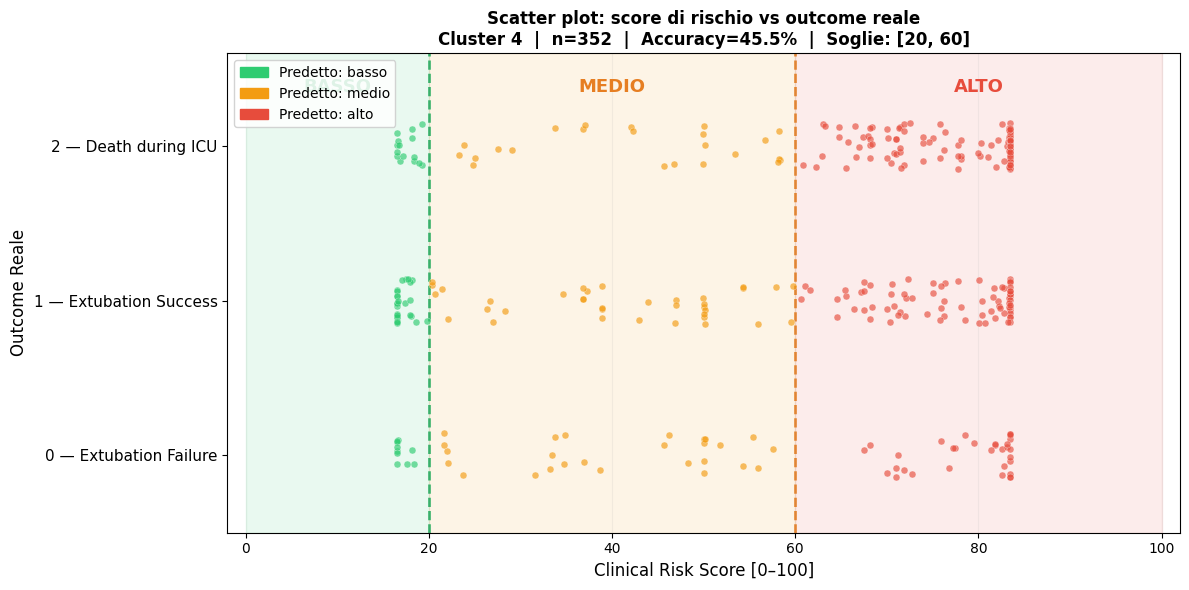

 Scatter Cluster 4 salvato in 'scatter_clinical_risk_cluster4.png'


In [39]:
# ============================================================
# CELL 18 – CLUSTER 4
# Clinical Risk Score vs Outcome Reale
# ============================================================

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# ── Variabili Cluster 4 ──
best_t1_c4 = best_t1   # ← soglia Low/Medium  Cluster 4
best_t2_c4 = best_t2   # ← soglia Medium/High Cluster 4
acc_f_c4   = accuracy_score(
    results_df_c4['outcome'],
    results_df_c4['predicted_class']
)

print(f" Variabili Cluster 4 pronte!")
print(f"   → n pazienti : {len(results_df_c4)}")
print(f"   → t1         : {best_t1_c4}")
print(f"   → t2         : {best_t2_c4}")
print(f"   → Accuracy   : {acc_f_c4*100:.2f}%")

# ── Mappa colori per classe PREDETTA ──
color_map = {
    0: '#f39c12',   # Predetto: medio  → arancione
    1: '#2ecc71',   # Predetto: basso  → verde
    2: '#e74c3c'    # Predetto: alto   → rosso
}
label_map = {
    0: 'Predetto: medio',
    1: 'Predetto: basso',
    2: 'Predetto: alto'
}

# ── Figura ──
fig, ax = plt.subplots(figsize=(12, 6))

# --- Fasce verticali di sfondo ---
ax.axvspan(0,          best_t1_c4,
           color='#2ecc71', alpha=0.10, zorder=0)
ax.axvspan(best_t1_c4, best_t2_c4,
           color='#f39c12', alpha=0.10, zorder=0)
ax.axvspan(best_t2_c4, 100,
           color='#e74c3c', alpha=0.10, zorder=0)

# --- Linee verticali soglia ---
ax.axvline(x=best_t1_c4,
           color='#27ae60', linestyle='--',
           linewidth=1.8, zorder=1)
ax.axvline(x=best_t2_c4,
           color='#e67e22', linestyle='--',
           linewidth=1.8, zorder=1)

# --- Etichette fasce ---
ax.text(best_t1_c4 / 2,
        2.38, 'BASSO',
        color='#27ae60', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)
ax.text((best_t1_c4 + best_t2_c4) / 2,
        2.38, 'MEDIO',
        color='#e67e22', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)
ax.text((best_t2_c4 + 100) / 2,
        2.38, 'ALTO',
        color='#e74c3c', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)

# --- Scatter per classe predetta ---
np.random.seed(42)
for pred_class in [1, 0, 2]:
    mask   = (results_df_c4['predicted_class']
               == pred_class)
    subset = results_df_c4[mask].reset_index(drop=True)
    jitter = np.random.uniform(
        -0.15, 0.15, size=len(subset)
    )
    ax.scatter(
        subset['clinical_risk'],
        subset['outcome'] + jitter,
        color=color_map[pred_class],
        label=label_map[pred_class],
        alpha=0.65,
        s=25,
        edgecolors='white',
        linewidths=0.3,
        zorder=3
    )

# --- Asse Y ---
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([
    '0 — Extubation Failure',
    '1 — Extubation Success',
    '2 — Death during ICU'
], fontsize=11)

# --- Asse X ---
ax.set_xlim([-2, 102])
ax.set_ylim([-0.5, 2.6])
ax.set_xlabel('Clinical Risk Score [0–100]',
              fontsize=12)
ax.set_ylabel('Outcome Reale', fontsize=12)

# --- Titolo ---
ax.set_title(
    f'Scatter plot: score di rischio vs outcome reale\n'
    f'Cluster 4  |  n={len(results_df_c4)}  |  '
    f'Accuracy={acc_f_c4*100:.1f}%  |  '
    f'Soglie: [{best_t1_c4}, {best_t2_c4}]',
    fontsize=12, fontweight='bold'
)

# --- Legenda ---
handles = [
    mpatches.Patch(color='#2ecc71',
                   label='Predetto: basso'),
    mpatches.Patch(color='#f39c12',
                   label='Predetto: medio'),
    mpatches.Patch(color='#e74c3c',
                   label='Predetto: alto'),
]
ax.legend(handles=handles, fontsize=10,
          loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.15, axis='x')

plt.tight_layout()
plt.savefig('scatter_clinical_risk_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter Cluster 4 salvato in "
      "'scatter_clinical_risk_cluster4.png'")


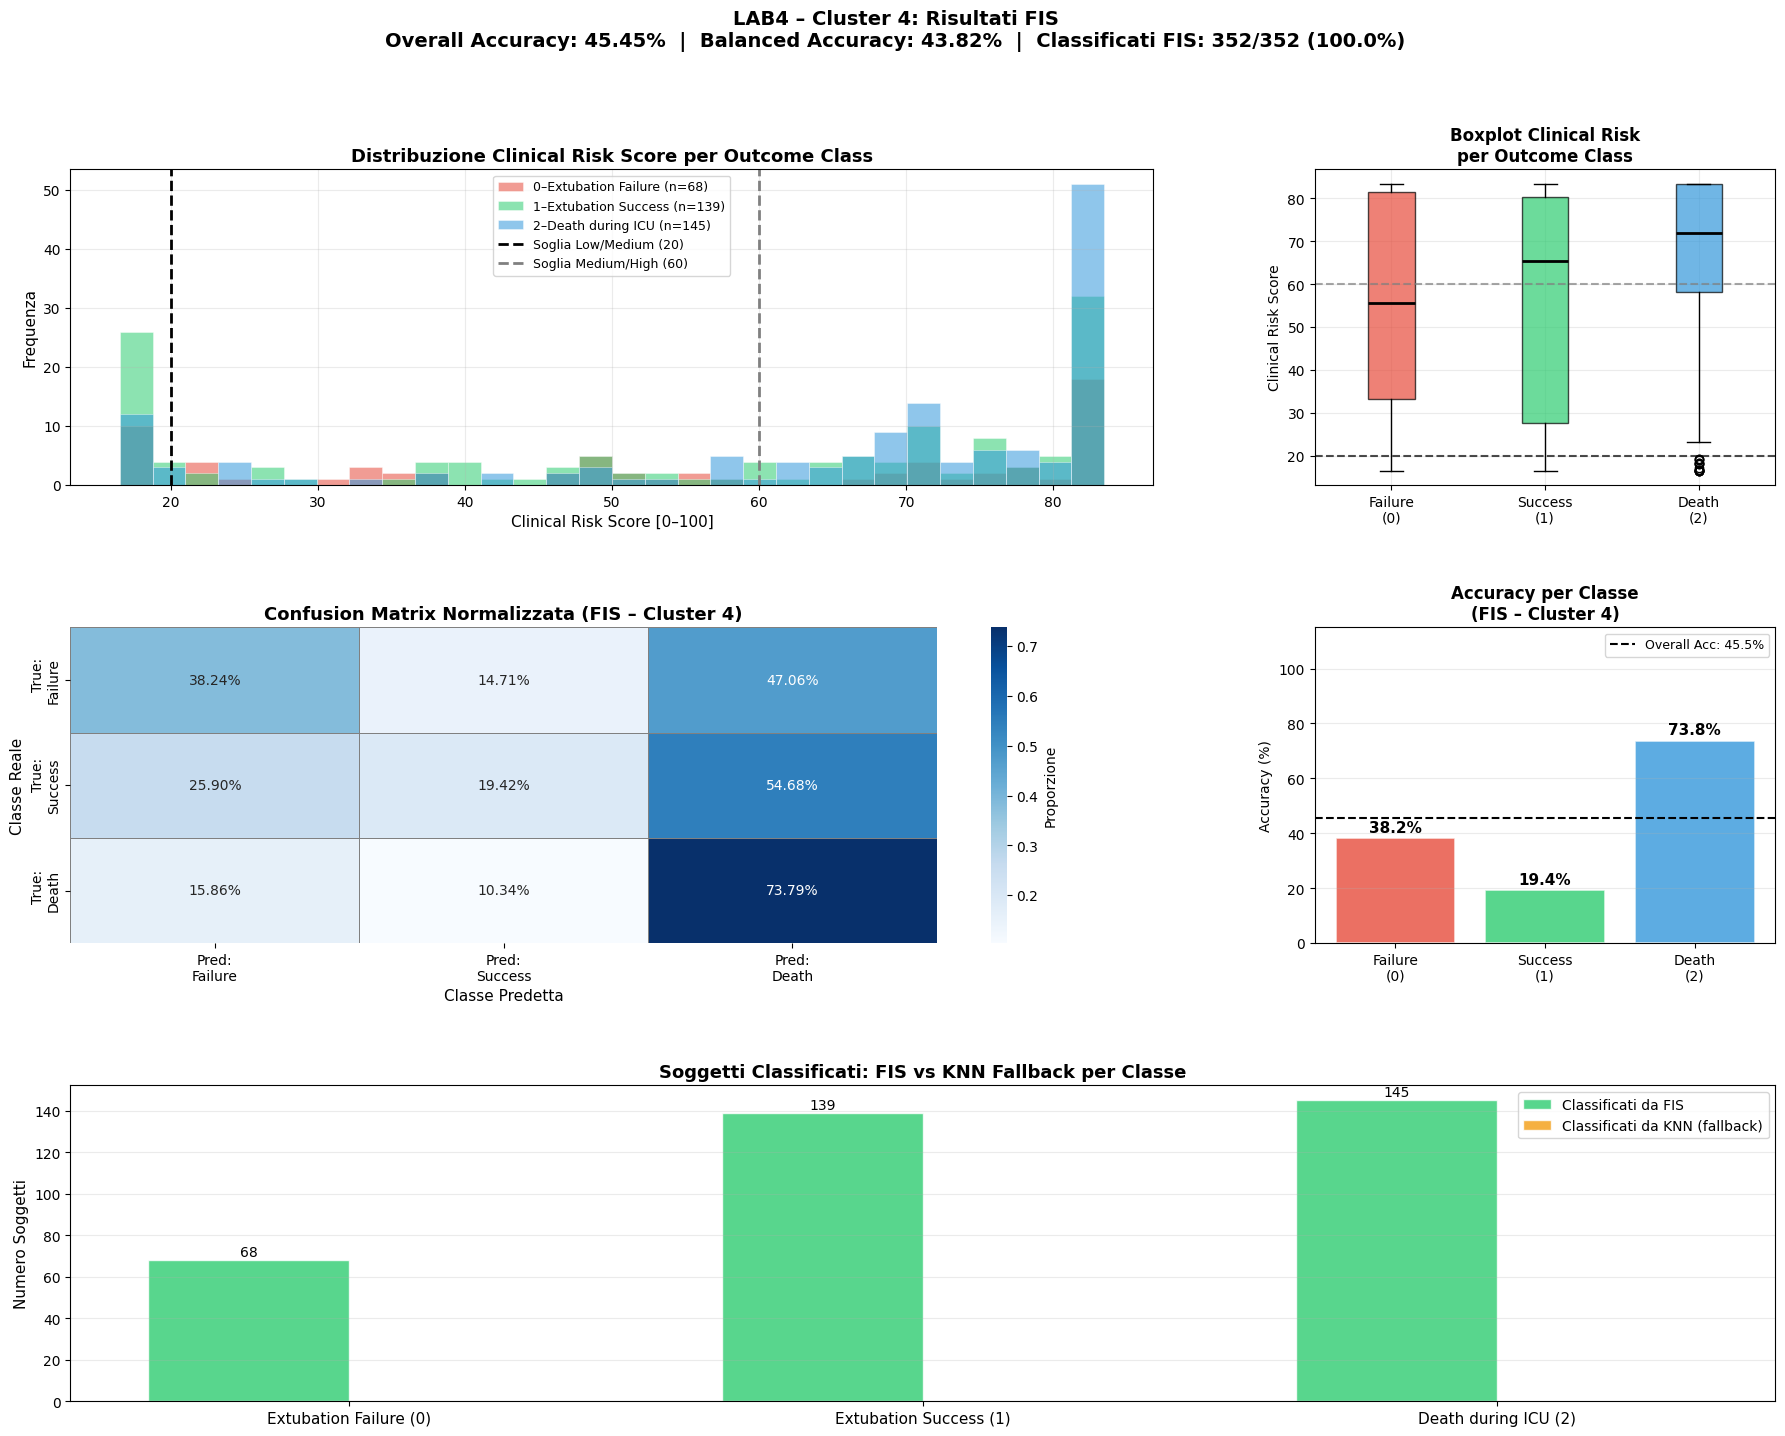

 Grafici salvati in 'FIS_results_cluster4.png'


In [40]:
# ============================================================
# CELL 19 – CLUSTER 4 – Visualizzazione Risultati
# ============================================================

fig = plt.figure(figsize=(22, 16))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Plot 1: Distribuzione score ──
ax1 = fig.add_subplot(gs[0, :2])
for c in [0, 1, 2]:
    subset = results_df_c4[
        results_df_c4['outcome'] == c
    ]['clinical_risk']
    ax1.hist(subset, bins=30, alpha=0.55,
             color=colors_class[c],
             label=f'{labels_class[c]} (n={len(subset)})',
             edgecolor='white', linewidth=0.5)
ax1.axvline(x=best_t1, color='black', linestyle='--',
            linewidth=2,
            label=f'Soglia Low/Medium ({best_t1})')
ax1.axvline(x=best_t2, color='grey', linestyle='--',
            linewidth=2,
            label=f'Soglia Medium/High ({best_t2})')
ax1.set_title(
    'Distribuzione Clinical Risk Score '
    'per Outcome Class',
    fontsize=13, fontweight='bold'
)
ax1.set_xlabel('Clinical Risk Score [0–100]',
               fontsize=11)
ax1.set_ylabel('Frequenza', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# ── Plot 2: Boxplot ──
ax2 = fig.add_subplot(gs[0, 2])
data_box = [
    results_df_c4[
        results_df_c4['outcome'] == c
    ]['clinical_risk'].values
    for c in [0, 1, 2]
]
bp = ax2.boxplot(data_box, patch_artist=True,
                  medianprops=dict(color='black',
                                   linewidth=2))
for patch, c in zip(bp['boxes'], [0, 1, 2]):
    patch.set_facecolor(colors_class[c])
    patch.set_alpha(0.7)
ax2.axhline(y=best_t1, color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.axhline(y=best_t2, color='grey', linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.set_xticklabels(
    ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
    fontsize=10
)
ax2.set_title(
    'Boxplot Clinical Risk\nper Outcome Class',
    fontsize=12, fontweight='bold'
)
ax2.set_ylabel('Clinical Risk Score', fontsize=10)
ax2.grid(True, alpha=0.25)

# ── Plot 3: Confusion Matrix ──
ax3 = fig.add_subplot(gs[1, :2])
cm_norm_c4 = confusion_matrix(
    y_true_c4, y_pred_c4,
    labels=[0, 1, 2], normalize='true'
)
sns.heatmap(
    cm_norm_c4,
    annot=True, fmt='.2%',
    cmap='Blues', ax=ax3,
    xticklabels=['Pred:\nFailure',
                 'Pred:\nSuccess',
                 'Pred:\nDeath'],
    yticklabels=['True:\nFailure',
                 'True:\nSuccess',
                 'True:\nDeath'],
    linewidths=0.5, linecolor='grey',
    cbar_kws={'label': 'Proporzione'}
)
ax3.set_title(
    'Confusion Matrix Normalizzata (FIS – Cluster 4)',
    fontsize=13, fontweight='bold'
)
ax3.set_xlabel('Classe Predetta', fontsize=11)
ax3.set_ylabel('Classe Reale', fontsize=11)

# ── Plot 4: Accuracy per classe ──
ax4 = fig.add_subplot(gs[1, 2])
per_class_acc_c4 = []
for c in [0, 1, 2]:
    mask  = y_true_c4 == c
    acc_c = accuracy_score(
        y_true_c4[mask], y_pred_c4[mask]
    )
    per_class_acc_c4.append(acc_c)

bars = ax4.bar(
    ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
    [a * 100 for a in per_class_acc_c4],
    color=[colors_class[c] for c in [0, 1, 2]],
    alpha=0.8, edgecolor='white', linewidth=1.2
)
for bar, acc_c in zip(bars, per_class_acc_c4):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{acc_c*100:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax4.axhline(y=acc_f * 100, color='black',
            linestyle='--', linewidth=1.5,
            label=f'Overall Acc: {acc_f*100:.1f}%')
ax4.set_title(
    'Accuracy per Classe\n(FIS – Cluster 4)',
    fontsize=12, fontweight='bold'
)
ax4.set_ylabel('Accuracy (%)', fontsize=10)
ax4.set_ylim([0, 115])
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25, axis='y')

# ── Plot 5: FIS vs KNN per classe ──
ax5 = fig.add_subplot(gs[2, :])
x     = np.arange(3)
width = 0.35

if 'knn_fallback' in results_df_c4.columns:
    n_fis_per_class = [
        (~results_df_c4['knn_fallback'] &
         (results_df_c4['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [
        (results_df_c4['knn_fallback'] &
         (results_df_c4['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
else:
    n_fis_per_class = [
        (results_df_c4['outcome'] == c).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [0, 0, 0]

bars1 = ax5.bar(x - width/2, n_fis_per_class, width,
                label='Classificati da FIS',
                color='#2ecc71', alpha=0.8,
                edgecolor='white')
bars2 = ax5.bar(x + width/2, n_knn_per_class, width,
                label='Classificati da KNN (fallback)',
                color='#f39c12', alpha=0.8,
                edgecolor='white')

for bar in bars1:
    if bar.get_height() > 0:
        ax5.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10
        )
for bar in bars2:
    if bar.get_height() > 0:
        ax5.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10
        )

ax5.set_xticks(x)
ax5.set_xticklabels([
    'Extubation Failure (0)',
    'Extubation Success (1)',
    'Death during ICU (2)'
], fontsize=11)
ax5.set_title(
    'Soggetti Classificati: FIS vs KNN Fallback '
    'per Classe',
    fontsize=13, fontweight='bold'
)
ax5.set_ylabel('Numero Soggetti', fontsize=11)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.25, axis='y')

n_fis_tot = sum(n_fis_per_class)
n_knn_tot = sum(n_knn_per_class)
n_tot_fig = len(results_df_c4)

fig.suptitle(
    f'LAB4 – Cluster 4: Risultati FIS\n'
    f'Overall Accuracy: {acc_f*100:.2f}%  |  '
    f'Balanced Accuracy: {bal_acc_f*100:.2f}%  |  '
    f'Classificati FIS: {n_fis_tot}/{n_tot_fig} '
    f'({n_fis_tot/n_tot_fig*100:.1f}%)',
    fontsize=14, fontweight='bold'
)
plt.savefig('FIS_results_cluster4.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Grafici salvati in 'FIS_results_cluster4.png'")


In [42]:
# ============================================================
# CELL 20 – CLUSTER 4 – Riepilogo Finale
# ============================================================

n_tot = len(results_df_c4)
if 'knn_fallback' in results_df_c4.columns:
    n_fis = (~results_df_c4['knn_fallback']).sum()
    n_knn = results_df_c4['knn_fallback'].sum()
else:
    n_fis = results_df_c4['clinical_risk'].notna().sum()
    n_knn = 0

print("=" * 65)
print("  RIEPILOGO FINALE – LAB4 CLUSTER 4")
print("=" * 65)
print(f"""
   Dataset
     → Soggetti Cluster 4     : {n_tot}
     → Feature selezionate    : {len(feature_cols_cluster4)}
     → Outcome classes        : 3
       • 0–Extubation Failure : {(y==0).sum()}
       • 1–Extubation Success : {(y==1).sum()}
       • 2–Death during ICU   : {(y==2).sum()}

   Fuzzy Inference System
     → Variabili input        : {len(feature_cols_cluster4)}
     → Variabili output       : 1 (clinical_risk)
     → Regole totali          : {len(rules_cluster4)}

   Performance
     → Overall Accuracy       : {acc_f*100:.2f}%
     → Balanced Accuracy      : {bal_acc_f*100:.2f}%
     → Classificati da FIS    : {n_fis} ({n_fis/n_tot*100:.1f}%)
     → Classificati da KNN    : {n_knn} ({n_knn/n_tot*100:.1f}%)
     → Soglia Low/Medium      : {best_t1}
     → Soglia Medium/High     : {best_t2}

   File salvati
     → histograms_cluster4.png
     → boxplots_cluster4.png
     → MF_continuous_cluster4.png
     → MF_binary_cluster4.png
     → dendrograms_cluster4.png
     → fuzzy_rules_cluster4.xlsx
     → FIS_results_cluster4.png
""")


  RIEPILOGO FINALE – LAB4 CLUSTER 4

   Dataset
     → Soggetti Cluster 4     : 352
     → Feature selezionate    : 8
     → Outcome classes        : 3
       • 0–Extubation Failure : 68
       • 1–Extubation Success : 139
       • 2–Death during ICU   : 145

   Fuzzy Inference System
     → Variabili input        : 8
     → Variabili output       : 1 (clinical_risk)
     → Regole totali          : 20

   Performance
     → Overall Accuracy       : 45.45%
     → Balanced Accuracy      : 43.82%
     → Classificati da FIS    : 352 (100.0%)
     → Classificati da KNN    : 0 (0.0%)
     → Soglia Low/Medium      : 20
     → Soglia Medium/High     : 60

   File salvati
     → histograms_cluster4.png
     → boxplots_cluster4.png
     → MF_continuous_cluster4.png
     → MF_binary_cluster4.png
     → dendrograms_cluster4.png
     → fuzzy_rules_cluster4.xlsx
     → FIS_results_cluster4.png

